In [ ]:
!nvidia-smi

Tue Aug 12 11:23:40 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.247.01             Driver Version: 535.247.01   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 4090        On  | 00000000:65:00.0 Off |                  Off |
| 41%   51C    P2             202W / 450W |   6995MiB / 24564MiB |     62%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [ ]:
!pip install --upgrade supervision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.2/207.2 kB 17.3 MB/s eta 0:00:00


In [ ]:
pwd

'/mnt/8tb_hdd/trash_detection/truong/RFDETR_model/littering-2classes'

In [ ]:
import zipfile
zip_file_path = '409image.v1i.coco.zip'

destination_folder = 'dataset'

try:
    os.makedirs(destination_folder, exist_ok=True)
    print(f"Đã đảm bảo thư mục đích tồn tại: '{destination_folder}'")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(destination_folder)

    print(f"✅ Đã giải nén thành công vào '{destination_folder}'")

except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy tệp zip tại '{zip_file_path}'. Vui lòng kiểm tra lại đường dẫn.")
except zipfile.BadZipFile:
    print(f"Lỗi: Tệp '{zip_file_path}' không phải là một tệp zip hợp lệ hoặc đã bị hỏng.")
except Exception as e:
    print(f"Đã xảy ra lỗi không mong muốn: {e}")

Đã đảm bảo thư mục đích tồn tại: 'dataset'
✅ Đã giải nén thành công vào 'dataset'


In [ ]:
pwd

'/mnt/8tb_hdd/trash_detection/truong/RFDETR_model/409-image'

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q rfdetr==1.1.0

In [ ]:
#!find /content/drive/MyDrive -iname "*rfdetr*"

/content/drive/MyDrive/Colab Notebooks/test_RFDETR
/content/drive/MyDrive/Colab Notebooks/test_RFDETR/fine_tune_RFDETR.ipynb


## TEST BASELINE MODEL

In [ ]:
from rfdetr import RFDETRBase

my_dataset_path = "2000-images"

model = RFDETRBase()

model.train(
    dataset_dir=my_dataset_path,
    epochs=5,
    batch_size=2,
    grad_accum_steps=4,
    lr=1e-4
)

2025-08-07 10:26:54.371989: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-07 10:26:54.384962: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-07 10:26:54.399098: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-07 10:26:54.403367: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-07 10:26:54.415733: I tensorflow/core/platform/cpu_feature_guar

Loading pretrain weights


num_classes mismatch: model has 90 classes, but your dataset has 2 classes
reinitializing your detection head with 2 classes.


TensorBoard logging initialized. To monitor logs, use 'tensorboard --logdir output' and open http://localhost:6006/ in browser.
Not using distributed mode
git:
  sha: N/A, status: clean, branch: N/A

Namespace(num_classes=2, grad_accum_steps=4, amp=True, lr=0.0001, lr_encoder=0.00015, batch_size=2, weight_decay=0.0001, epochs=5, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-base.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_load=None, pretrained_distiller=None, encoder='dinov2_windowed_small', vit_encoder_num_layers=12, window_block_indexes=None, position_embedding='sine', out_feature_indexes=[2, 5, 8, 11], freeze_encoder=False, layer_norm=True, rms_norm=False, backbone_lora=False, force_no_pretrain=False, dec_layers=3, dim_feedforward=2048, hidden_dim=256, sa_nheads=8, ca_nheads=16

fatal: not a git repository (or any of the parent directories): .git


Epoch: [0]  [  0/191]  eta: 0:05:50  lr: 0.000100  class_error: 96.15  loss: 17.7467 (17.7467)  loss_ce: 0.1214 (0.1214)  loss_bbox: 1.4522 (1.4522)  loss_giou: 2.5171 (2.5171)  loss_ce_0: 0.1083 (0.1083)  loss_bbox_0: 1.7171 (1.7171)  loss_giou_0: 2.7701 (2.7701)  loss_ce_1: 0.1379 (0.1379)  loss_bbox_1: 1.3291 (1.3291)  loss_giou_1: 2.7047 (2.7047)  loss_ce_enc: 0.0903 (0.0903)  loss_bbox_enc: 1.8876 (1.8876)  loss_giou_enc: 2.9107 (2.9107)  loss_ce_unscaled: 0.1214 (0.1214)  class_error_unscaled: 96.1538 (96.1538)  loss_bbox_unscaled: 0.2904 (0.2904)  loss_giou_unscaled: 1.2585 (1.2585)  cardinality_error_unscaled: 3771.5000 (3771.5000)  loss_ce_0_unscaled: 0.1083 (0.1083)  loss_bbox_0_unscaled: 0.3434 (0.3434)  loss_giou_0_unscaled: 1.3850 (1.3850)  cardinality_error_0_unscaled: 3270.5000 (3270.5000)  loss_ce_1_unscaled: 0.1379 (0.1379)  loss_bbox_1_unscaled: 0.2658 (0.2658)  loss_giou_1_unscaled: 1.3523 (1.3523)  cardinality_error_1_unscaled: 2296.0000 (2296.0000)  loss_ce_enc_uns

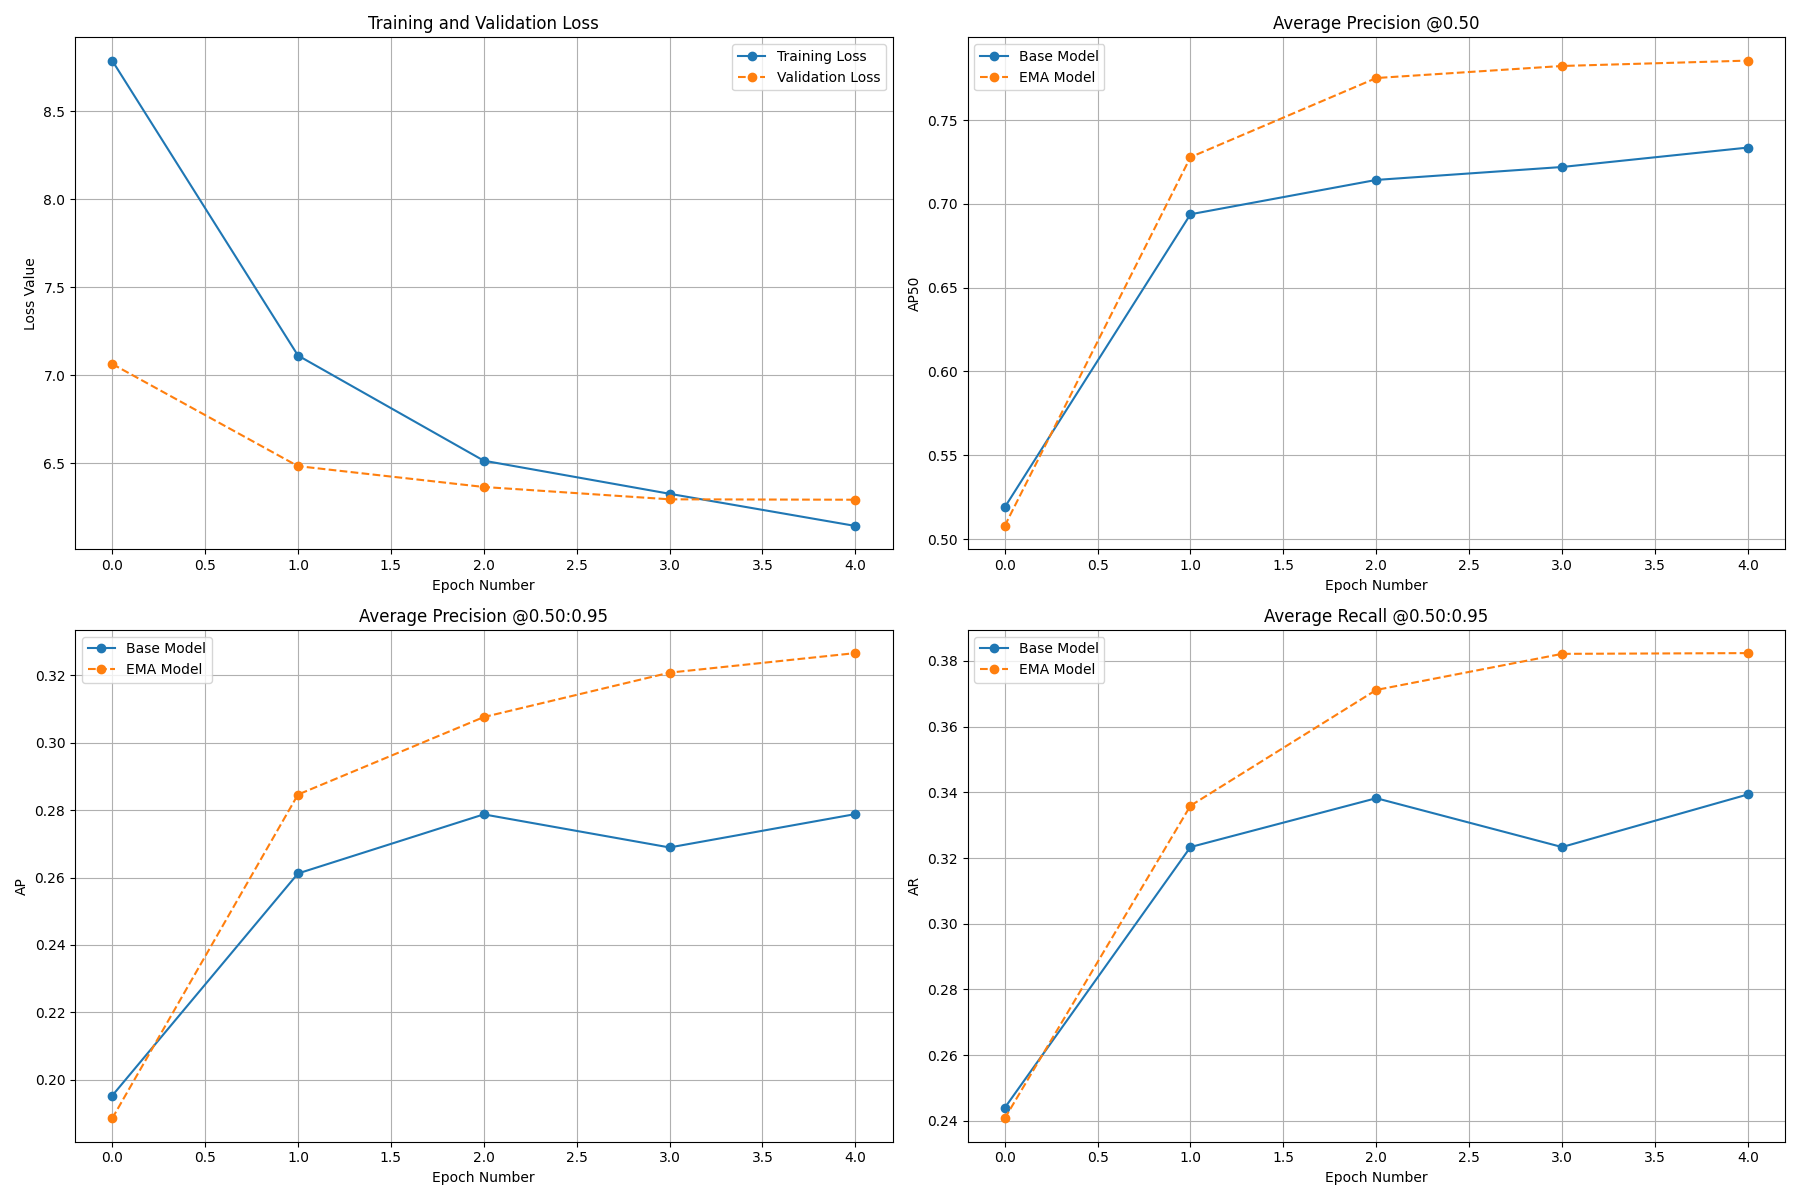

In [ ]:
from PIL import Image

Image.open("output/metrics_plot.png")

In [ ]:
import supervision as sv

my_test_path = "2000-images/test"

ds = sv.DetectionDataset.from_coco(
    images_directory_path=my_test_path,
    annotations_path=f"{my_test_path}/_annotations.coco.json",
)

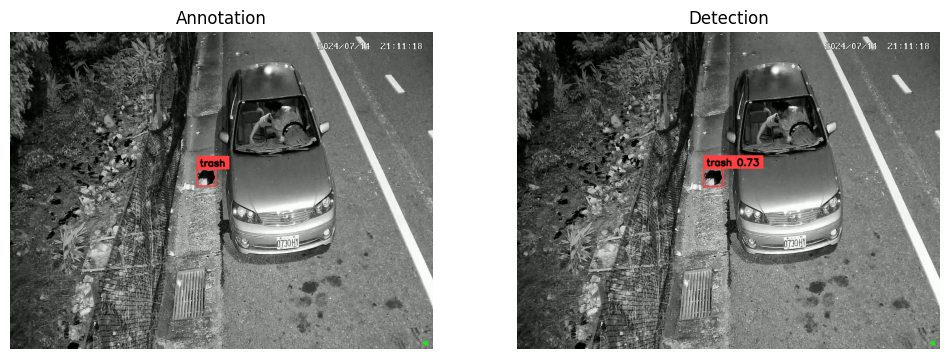

In [ ]:
from rfdetr import RFDETRBase
import supervision as sv
from PIL import Image

path, image, annotations = ds[0]
image = Image.open(path)

detections = model.predict(image, threshold=0.5)

text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)

bbox_annotator = sv.BoxAnnotator(thickness=thickness)
label_annotator = sv.LabelAnnotator(
    text_color=sv.Color.BLACK,
    text_scale=text_scale,
    text_thickness=thickness,
    smart_position=True)

annotations_labels = [
    f"{ds.classes[class_id]}"
    for class_id
    in annotations.class_id
]

detections_labels = [
    f"{ds.classes[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotation_image = image.copy()
annotation_image = bbox_annotator.annotate(annotation_image, annotations)
annotation_image = label_annotator.annotate(annotation_image, annotations, annotations_labels)

detections_image = image.copy()
detections_image = bbox_annotator.annotate(detections_image, detections)
detections_image = label_annotator.annotate(detections_image, detections, detections_labels)

sv.plot_images_grid(images=[annotation_image, detections_image], grid_size=(1, 2), titles=["Annotation", "Detection"])

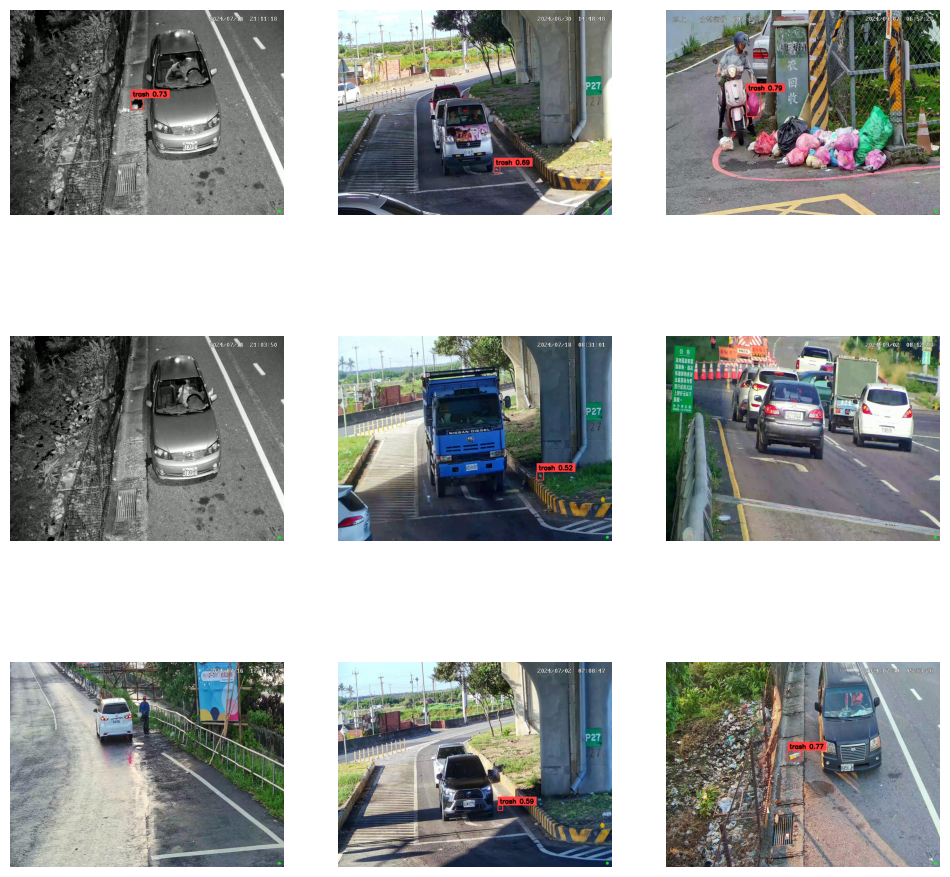

In [ ]:
import supervision as sv
from rfdetr import RFDETRBase
from PIL import Image

detections_images = []

for i in range(9):
    path, image, annotations = ds[i]
    image = Image.open(path)

    detections = model.predict(image, threshold=0.5)

    text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
    thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)

    bbox_annotator = sv.BoxAnnotator(thickness=thickness)
    label_annotator = sv.LabelAnnotator(
        text_color=sv.Color.BLACK,
        text_scale=text_scale,
        text_thickness=thickness,
        smart_position=True)

    detections_labels = [
        f"{ds.classes[class_id]} {confidence:.2f}"
        for class_id, confidence
        in zip(detections.class_id, detections.confidence)
    ]

    detections_image = image.copy()
    detections_image = bbox_annotator.annotate(detections_image, detections)
    detections_image = label_annotator.annotate(detections_image, detections, detections_labels)

    detections_images.append(detections_image)

sv.plot_images_grid(images=detections_images, grid_size=(3, 3), size=(12, 12))

In [ ]:
import supervision as sv
from tqdm import tqdm
from supervision.metrics import MeanAveragePrecision

targets = []
predictions = []

for path, image, annotations in tqdm(ds):
    image = Image.open(path)
    detections = model.predict(image, threshold=0.5)

    targets.append(annotations)
    predictions.append(detections)

100%|██████████| 216/216 [00:09<00:00, 23.29it/s]


Đang vẽ biểu đồ...


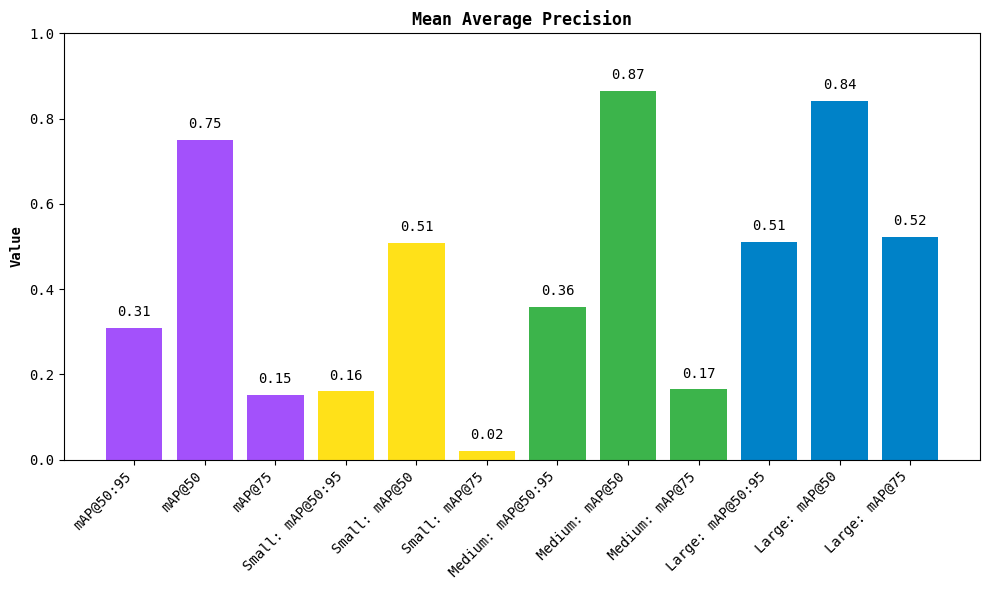

✅ Đã lưu biểu đồ kết quả thành công vào file: output/map_result_test1.png


In [ ]:
import os
import matplotlib.pyplot as plt
from supervision.metrics import MeanAveragePrecision

map_metric = MeanAveragePrecision()
map_result = map_metric.update(predictions, targets).compute()

output_dir = "output"

os.makedirs(output_dir, exist_ok=True)

filename = "map_result_test1.png"

full_output_path = os.path.join(output_dir, filename)

print("Đang vẽ biểu đồ...")
map_result.plot()
fig = plt.gcf()

fig.savefig(full_output_path, dpi=300)
plt.close(fig)

print(f"✅ Đã lưu biểu đồ kết quả thành công vào file: {full_output_path}")

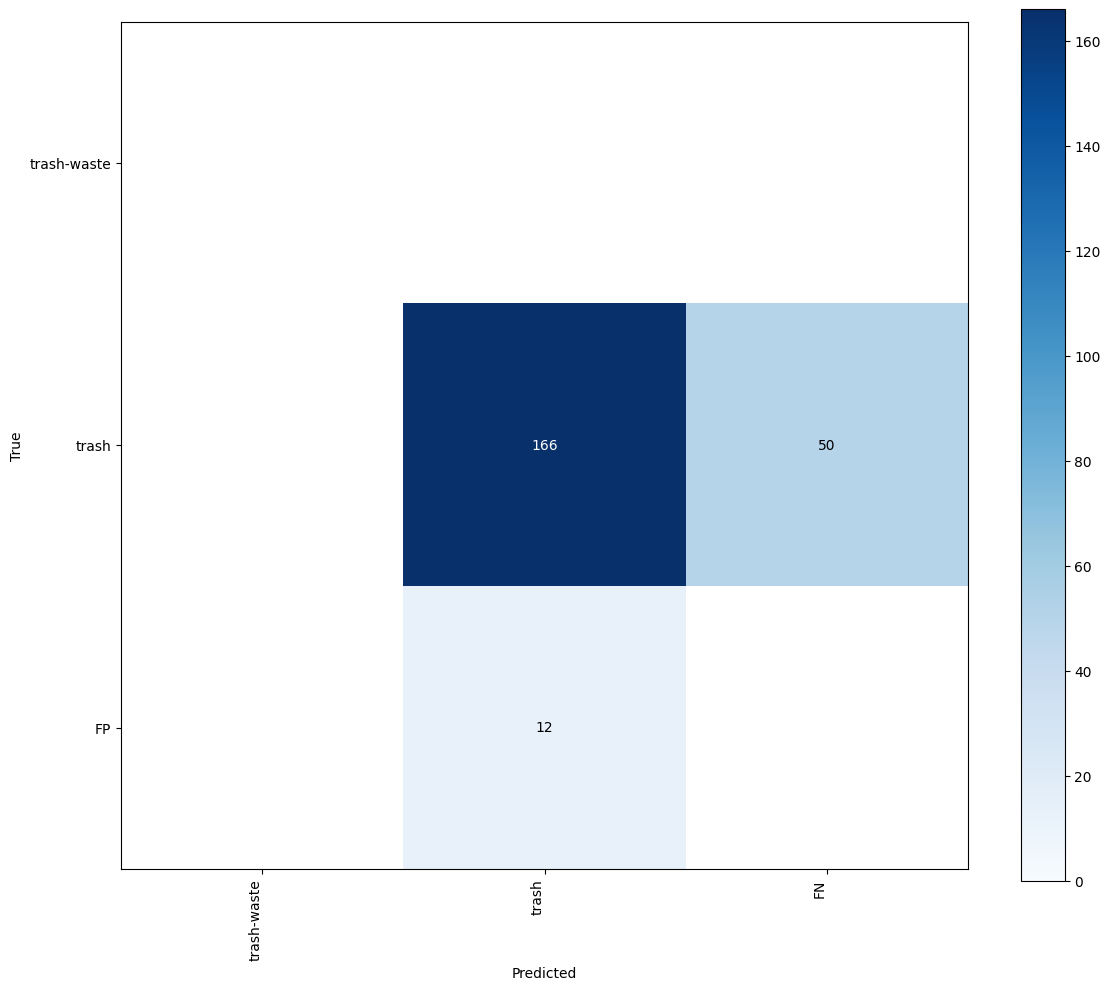

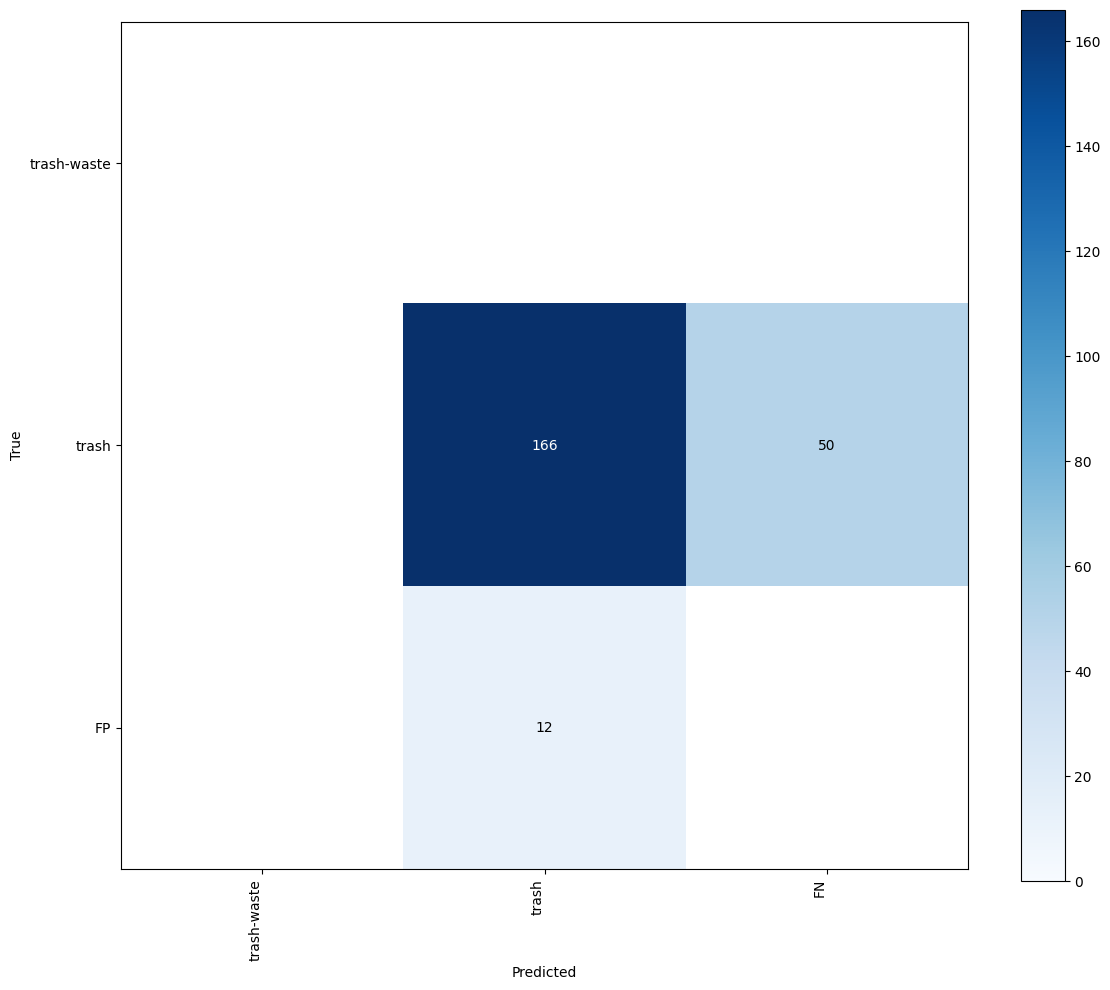

In [ ]:
confusion_matrix = sv.ConfusionMatrix.from_detections(
    predictions=predictions,
    targets=targets,
    classes=ds.classes
)

confusion_matrix.plot()

# BASE MODEL 20 EPOCHS

In [ ]:
from rfdetr import RFDETRBase

my_dataset_path = "dataset"

model = RFDETRBase()

model.train(
    dataset_dir=my_dataset_path,
    epochs=50,
    batch_size=4,
    grad_accum_steps=4,

    lr=1e-4,
    lr_scheduler='cosine',
    lr_warmup_epochs=5,

    weight_decay=1e-4,

    # 3. Early Stopping (Đã điều chỉnh)
    #early_stopping_patience=20, # Giữ ở mức hợp lý
    #early_stopping_metric='mAP',
    # THÊM MỚI: Đặt mức cải thiện tối thiểu để reset patience
    #early_stopping_min_delta=0.05,

    use_mosaic=True,

    use_blur=True
)

print("Hoàn tất quá trình training!")

Loading pretrain weights


num_classes mismatch: model has 90 classes, but your dataset has 2 classes
reinitializing your detection head with 2 classes.


TensorBoard logging initialized. To monitor logs, use 'tensorboard --logdir output' and open http://localhost:6006/ in browser.
Not using distributed mode
git:
  sha: N/A, status: clean, branch: N/A

Namespace(num_classes=2, grad_accum_steps=4, amp=True, lr=0.0001, lr_encoder=0.00015, batch_size=4, weight_decay=0.0001, epochs=50, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-base.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_load=None, pretrained_distiller=None, encoder='dinov2_windowed_small', vit_encoder_num_layers=12, window_block_indexes=None, position_embedding='sine', out_feature_indexes=[2, 5, 8, 11], freeze_encoder=False, layer_norm=True, rms_norm=False, backbone_lora=False, force_no_pretrain=False, dec_layers=3, dim_feedforward=2048, hidden_dim=256, sa_nheads=8, ca_nheads=1

fatal: not a git repository (or any of the parent directories): .git


Epoch: [0]  [ 0/20]  eta: 0:00:22  lr: 0.000100  class_error: 42.31  loss: 18.5578 (18.5578)  loss_ce: 0.3061 (0.3061)  loss_bbox: 1.6208 (1.6208)  loss_giou: 2.4252 (2.4252)  loss_ce_0: 0.2961 (0.2961)  loss_bbox_0: 2.0401 (2.0401)  loss_giou_0: 2.4695 (2.4695)  loss_ce_1: 0.3013 (0.3013)  loss_bbox_1: 1.7079 (1.7079)  loss_giou_1: 2.4708 (2.4708)  loss_ce_enc: 0.2948 (0.2948)  loss_bbox_enc: 2.2503 (2.2503)  loss_giou_enc: 2.3749 (2.3749)  loss_ce_unscaled: 0.3061 (0.3061)  class_error_unscaled: 42.3077 (42.3077)  loss_bbox_unscaled: 0.3242 (0.3242)  loss_giou_unscaled: 1.2126 (1.2126)  cardinality_error_unscaled: 2984.7500 (2984.7500)  loss_ce_0_unscaled: 0.2961 (0.2961)  loss_bbox_0_unscaled: 0.4080 (0.4080)  loss_giou_0_unscaled: 1.2347 (1.2347)  cardinality_error_0_unscaled: 2488.5000 (2488.5000)  loss_ce_1_unscaled: 0.3013 (0.3013)  loss_bbox_1_unscaled: 0.3416 (0.3416)  loss_giou_1_unscaled: 1.2354 (1.2354)  cardinality_error_1_unscaled: 3511.7500 (3511.7500)  loss_ce_enc_unsca

In [ ]:
from PIL import Image

Image.open("output/metrics_plot.png")

In [ ]:
import zipfile
zip_file_path = 'litter-video-test.zip'

destination_folder = 'test'

# --- Bắt đầu quá trình giải nén ---

try:
    os.makedirs(destination_folder, exist_ok=True)
    print(f"Đã đảm bảo thư mục đích tồn tại: '{destination_folder}'")

    # Mở tệp zip và giải nén
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(destination_folder)

    print(f"✅ Đã giải nén thành công vào '{destination_folder}'")

except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy tệp zip tại '{zip_file_path}'. Vui lòng kiểm tra lại đường dẫn.")
except zipfile.BadZipFile:
    print(f"Lỗi: Tệp '{zip_file_path}' không phải là một tệp zip hợp lệ hoặc đã bị hỏng.")
except Exception as e:
    print(f"Đã xảy ra lỗi không mong muốn: {e}")

Đã đảm bảo thư mục đích tồn tại: 'test'
✅ Đã giải nén thành công vào 'test'


In [ ]:
import cv2
import os
import supervision as sv
from PIL import Image
import numpy as np

video_directory_path = "test/litter-video-test"
output_directory_path = "predict-50-epochs"

class_names = ["human", "trash"]

video_files = [f for f in os.listdir(video_directory_path) if f.endswith('.mp4')]

if not video_files:
    print("Không tìm thấy video trong thư mục.")
else:
    for video_file in video_files:
        video_input_path = os.path.join(video_directory_path, video_file)
        video_output_path = os.path.join(output_directory_path, f"processed_{video_file}")

        cap = cv2.VideoCapture(video_input_path)

        if not cap.isOpened():
            print(f"Không thể mở video {video_file}")
            continue

        frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = int(cap.get(cv2.CAP_PROP_FPS))

        # Khởi tạo writer để lưu video mới
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(video_output_path, fourcc, fps, (frame_width, frame_height))

        # Tiến hành xử lý từng khung hình trong video
        while True:
            ret, frame = cap.read()

            if not ret:
                break

            # Chuyển đổi khung hình từ OpenCV (BGR) sang PIL (RGB)
            image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

            # Dự đoán đối tượng trong khung hình bằng mô hình đã huấn luyện
            detections = model.predict(image, threshold=0.5)

            # Tính toán độ dày đường viền và kích thước chữ tối ưu
            text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
            thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)

            # Tạo annotator cho bounding box và label
            bbox_annotator = sv.BoxAnnotator(thickness=thickness)
            label_annotator = sv.LabelAnnotator(
                text_color=sv.Color.BLACK,
                text_scale=text_scale,
                text_thickness=thickness,
                smart_position=True
            )

            # Gắn nhãn cho các đối tượng phát hiện, kiểm tra class_id trước khi truy cập class_names
            detections_labels = []
            for class_id, confidence in zip(detections.class_id, detections.confidence):
                if class_id >= len(class_names):
                    print(f"Warning: class_id {class_id} exceeds available class names. Assigning label 'Unknown'.")
                    detections_labels.append(f"Unknown {confidence:.2f}")
                else:
                    detections_labels.append(f"{class_names[class_id]} {confidence:.2f}")

            # Tạo bản sao khung hình và vẽ bounding box và nhãn
            frame_with_detections = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
            frame_with_detections = bbox_annotator.annotate(frame_with_detections, detections)
            frame_with_detections = label_annotator.annotate(frame_with_detections, detections, detections_labels)

            # Ghi khung hình đã có bounding box vào video output
            out.write(frame_with_detections)

        # Giải phóng tài nguyên
        cap.release()
        out.release()

        print(f"Video {video_file} đã được xử lý và lưu tại {video_output_path}.")

In [ ]:
import shutil
import os

# Đường dẫn tới thư mục cần nén
folder_path = 'predict-50-epochs'
zip_file_path = 'predich-50-epochs.zip'

shutil.make_archive(zip_file_path.replace('.zip', ''), 'zip', folder_path)

# Đưa tệp zip lên thư mục hiện tại của Jupyter
import shutil
from IPython.display import FileLink

# Tạo liên kết tải về tệp zip
FileLink(zip_file_path)

# Test large model rfdetr

In [ ]:
from rfdetr import RFDETRLarge

my_dataset_path = "dataset"

model = RFDETRLarge()

# Gọi hàm train với tham số đã điều chỉnh
model.train(
    dataset_dir=my_dataset_path,
    epochs=50,
    batch_size=4,
    grad_accum_steps=4,

    # 1. Learning Rate và Scheduler
    lr=1e-4,
    lr_scheduler='cosine',
    lr_warmup_epochs=5,

    # 2. Regularization
    weight_decay=1e-4,

    # 3. Early Stopping
    early_stopping_patience=20,
    early_stopping_metric='mAP',
    early_stopping_min_delta=0.05,

    # 4. Advanced Data Augmentation
    use_mosaic=True,
    use_blur=True
)

print("Hoàn tất quá trình training!")

2025-08-12 11:23:55.571145: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-12 11:23:55.583906: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-12 11:23:55.598591: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-12 11:23:55.602908: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-12 11:23:55.614474: I tensorflow/core/platform/cpu_feature_guar

Loading pretrain weights


num_classes mismatch: model has 90 classes, but your dataset has 2 classes
reinitializing your detection head with 2 classes.


TensorBoard logging initialized. To monitor logs, use 'tensorboard --logdir output' and open http://localhost:6006/ in browser.
Not using distributed mode
git:
  sha: N/A, status: clean, branch: N/A

Namespace(num_classes=2, grad_accum_steps=4, amp=True, lr=0.0001, lr_encoder=0.00015, batch_size=4, weight_decay=0.0001, epochs=50, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-large.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_load=None, pretrained_distiller=None, encoder='dinov2_windowed_base', vit_encoder_num_layers=12, window_block_indexes=None, position_embedding='sine', out_feature_indexes=[2, 5, 8, 11], freeze_encoder=False, layer_norm=True, rms_norm=False, backbone_lora=False, force_no_pretrain=False, dec_layers=3, dim_feedforward=2048, hidden_dim=384, sa_nheads=12, ca_nheads=

fatal: not a git repository (or any of the parent directories): .git


Epoch: [0]  [ 0/20]  eta: 0:00:59  lr: 0.000100  class_error: 3.85  loss: 14.5664 (14.5664)  loss_ce: 0.3542 (0.3542)  loss_bbox: 1.0812 (1.0812)  loss_giou: 2.0906 (2.0906)  loss_ce_0: 0.2712 (0.2712)  loss_bbox_0: 1.1473 (1.1473)  loss_giou_0: 2.2835 (2.2835)  loss_ce_1: 0.3090 (0.3090)  loss_bbox_1: 1.0224 (1.0224)  loss_giou_1: 2.2384 (2.2384)  loss_ce_enc: 0.2832 (0.2832)  loss_bbox_enc: 1.1948 (1.1948)  loss_giou_enc: 2.2907 (2.2907)  loss_ce_unscaled: 0.3542 (0.3542)  class_error_unscaled: 3.8462 (3.8462)  loss_bbox_unscaled: 0.2162 (0.2162)  loss_giou_unscaled: 1.0453 (1.0453)  cardinality_error_unscaled: 115.5000 (115.5000)  loss_ce_0_unscaled: 0.2712 (0.2712)  loss_bbox_0_unscaled: 0.2295 (0.2295)  loss_giou_0_unscaled: 1.1418 (1.1418)  cardinality_error_0_unscaled: 1786.5000 (1786.5000)  loss_ce_1_unscaled: 0.3090 (0.3090)  loss_bbox_1_unscaled: 0.2045 (0.2045)  loss_giou_1_unscaled: 1.1192 (1.1192)  cardinality_error_1_unscaled: 992.5000 (992.5000)  loss_ce_enc_unscaled: 0.

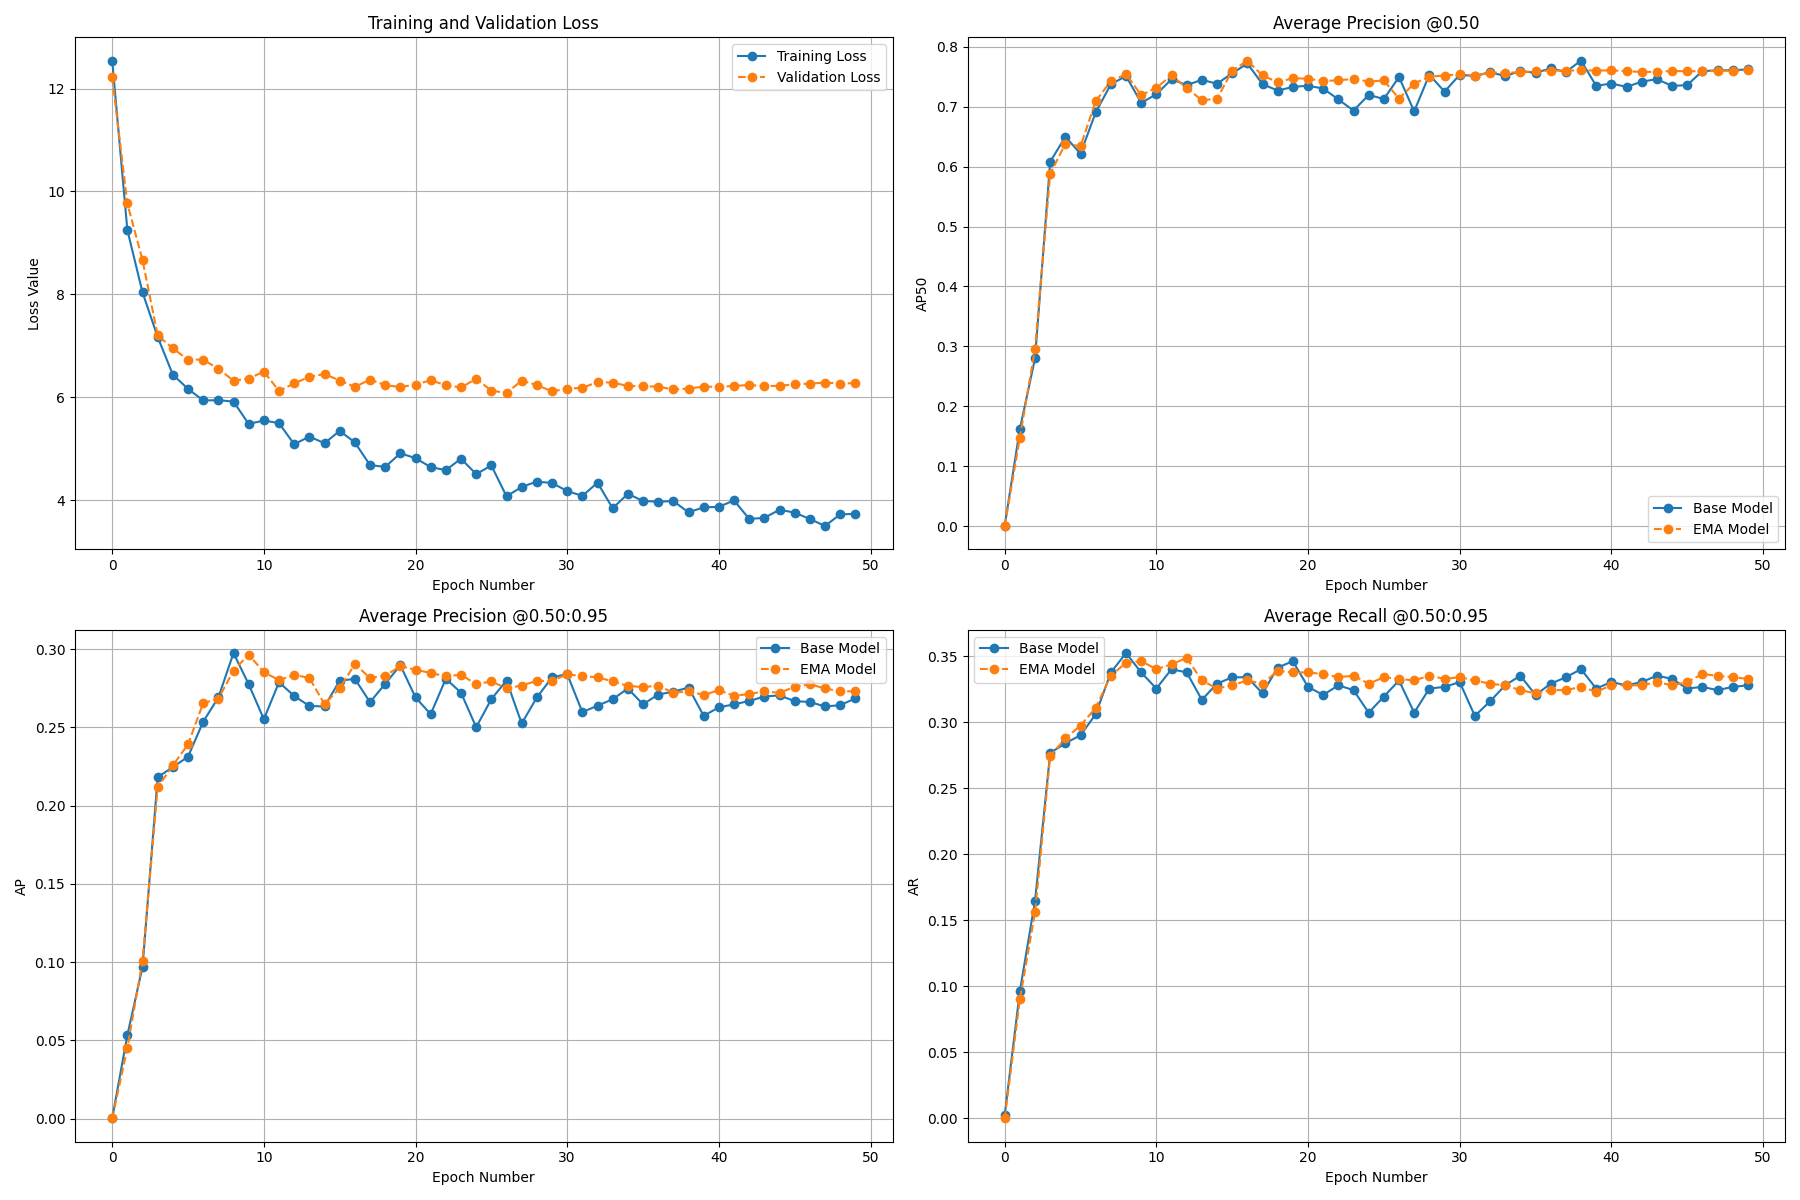

In [ ]:
from PIL import Image

Image.open("output/metrics_plot.png")

In [ ]:
import cv2
import os
import supervision as sv
from PIL import Image
import numpy as np

# Đường dẫn tới thư mục chứa các video test
video_directory_path = "test/litter-video-test"
output_directory_path = "predict-50-large"

# Gán trực tiếp danh sách các lớp
class_names = ["human", "trash"]

# Lấy danh sách tất cả các tệp video trong thư mục
video_files = [f for f in os.listdir(video_directory_path) if f.endswith('.mp4')]

# Kiểm tra nếu không có video nào
if not video_files:
    print("Không tìm thấy video trong thư mục.")
else:
    # Tiến hành xử lý từng video trong thư mục
    for video_file in video_files:
        video_input_path = os.path.join(video_directory_path, video_file)
        video_output_path = os.path.join(output_directory_path, f"processed_{video_file}")

        # Mở video
        cap = cv2.VideoCapture(video_input_path)

        # Kiểm tra nếu video mở thành công
        if not cap.isOpened():
            print(f"Không thể mở video {video_file}")
            continue

        # Lấy thông tin về video (kích thước khung hình và số khung hình mỗi giây)
        frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = int(cap.get(cv2.CAP_PROP_FPS))

        # Khởi tạo writer để lưu video mới
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(video_output_path, fourcc, fps, (frame_width, frame_height))

        # Tiến hành xử lý từng khung hình trong video
        while True:
            ret, frame = cap.read()

            if not ret:
                break

            # Chuyển đổi khung hình từ OpenCV (BGR) sang PIL (RGB)
            image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

            # Dự đoán đối tượng trong khung hình bằng mô hình đã huấn luyện
            detections = model.predict(image, threshold=0.5)

            # Tính toán độ dày đường viền và kích thước chữ tối ưu
            text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
            thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)

            # Tạo annotator cho bounding box và label
            bbox_annotator = sv.BoxAnnotator(thickness=thickness)
            label_annotator = sv.LabelAnnotator(
                text_color=sv.Color.BLACK,
                text_scale=text_scale,
                text_thickness=thickness,
                smart_position=True
            )

            # Gắn nhãn cho các đối tượng phát hiện, kiểm tra class_id trước khi truy cập class_names
            detections_labels = []
            for class_id, confidence in zip(detections.class_id, detections.confidence):
                if class_id >= len(class_names):
                    print(f"Warning: class_id {class_id} exceeds available class names. Assigning label 'Unknown'.")
                    detections_labels.append(f"Unknown {confidence:.2f}")
                else:
                    detections_labels.append(f"{class_names[class_id]} {confidence:.2f}")

            # Tạo bản sao khung hình và vẽ bounding box và nhãn
            frame_with_detections = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
            frame_with_detections = bbox_annotator.annotate(frame_with_detections, detections)
            frame_with_detections = label_annotator.annotate(frame_with_detections, detections, detections_labels)

            # Ghi khung hình đã có bounding box vào video output
            out.write(frame_with_detections)

        # Giải phóng tài nguyên
        cap.release()
        out.release()

        print(f"Video {video_file} đã được xử lý và lưu tại {video_output_path}.")

Video 20240605180713_56.mp4 đã được xử lý và lưu tại predict-50-large/processed_20240605180713_56.mp4.
Video 20240602164515_19.mp4 đã được xử lý và lưu tại predict-50-large/processed_20240602164515_19.mp4.
Video 20240606054407_59.mp4 đã được xử lý và lưu tại predict-50-large/processed_20240606054407_59.mp4.
Video 20240602115532_17.mp4 đã được xử lý và lưu tại predict-50-large/processed_20240602115532_17.mp4.
Video 20240605125051_57.mp4 đã được xử lý và lưu tại predict-50-large/processed_20240605125051_57.mp4.
Video 20240607091456_79S.mp4 đã được xử lý và lưu tại predict-50-large/processed_20240607091456_79S.mp4.
Video 20240605133830_52.mp4 đã được xử lý và lưu tại predict-50-large/processed_20240605133830_52.mp4.
Video 2024060290237_15.mp4 đã được xử lý và lưu tại predict-50-large/processed_2024060290237_15.mp4.
Video 20240602083629_2_14.mp4 đã được xử lý và lưu tại predict-50-large/processed_20240602083629_2_14.mp4.
Video 20240604155458_1_39.mp4 đã được xử lý và lưu tại predict-50-lar

In [ ]:
import shutil
import os

# Đường dẫn tới thư mục cần nén
folder_path = 'predict-50-large'
zip_file_path = 'predict-50-large.zip'

# Nén thư mục thành file .zip
shutil.make_archive(zip_file_path.replace('.zip', ''), 'zip', folder_path)

# Đưa tệp zip lên thư mục hiện tại của Jupyter
import shutil
from IPython.display import FileLink

# Tạo liên kết tải về tệp zip
FileLink(zip_file_path)

/mnt/8tb_hdd/trash_detection/truong/RFDETR_model/409-image/predict-50-large.zip